# Hyperparameter Sensitivity Analysis: LightGBMLSS vs LightGBM with Quantiles

This notebook analyzes and compares the sensitivity to hyperparameters between LightGBMLSS and LightGBM with quantile regression on synthetic Gaussian mixture datasets. The goal is to understand how changes in key hyperparameters affect the performance of both models in terms of quantile prediction accuracy.

## Objectives:
1. Generate the same synthetic Gaussian mixture data as in the original study
2. Implement a systematic approach to test hyperparameter sensitivity 
3. Compare the robustness of both models to hyperparameter changes
4. Visualize sensitivity patterns across different hyperparameters
5. Provide recommendations on hyperparameter tuning for each model

In [7]:
# Import Required Libraries
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import multivariate_normal
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
from lightgbm import LGBMRegressor

# LightGBMLSS imports
sys.path.append(os.path.abspath('..'))
from LightGBMLSS.lightgbmlss.model import LightGBMLSS
from LightGBMLSS.lightgbmlss.distributions.Gaussian import Gaussian
from utils.metrics import quantile_loss, crps

# For hyperparameter analysis
import optuna
from functools import partial
import time
from tqdm.notebook import tqdm
import itertools

# Set random seeds for reproducibility
np.random.seed(42)

# Plot settings
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


## Data Generation

We'll use the same synthetic data generation method from the original notebook to create Gaussian mixture datasets for our experiments.

Generating synthetic Gaussian mixture dataset...
Generated dataset with 5000 samples, 10 features, and 3 mixture components
Data shapes: X_train: (4000, 10), y_train: (4000,), X_test: (1000, 10), y_test: (1000,)


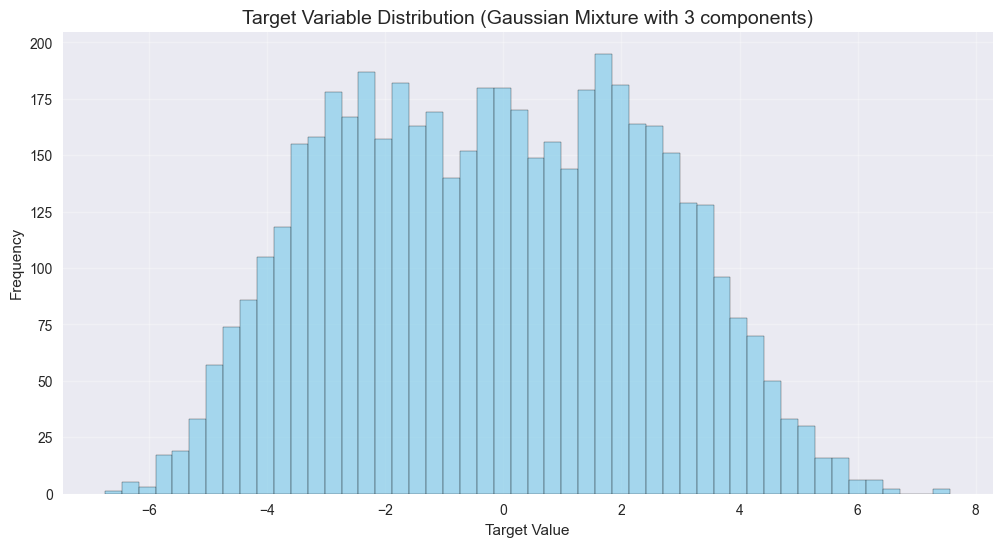

In [8]:
def generate_gaussian_mixture_data(n_samples=1000, n_features=10, n_components=2, noise_level=0.1, random_state=42):
    """
    Generate synthetic data with Gaussian mixture targets.
    
    Parameters:
    -----------
    n_samples : int
        Number of samples to generate
    n_features : int
        Number of input features
    n_components : int
        Number of components in the Gaussian mixture
    noise_level : float
        Amount of noise to add to the target
    random_state : int
        Random seed for reproducibility
    
    Returns:
    --------
    X : ndarray
        Feature matrix of shape (n_samples, n_features)
    y : ndarray
        Target vector following Gaussian mixture distribution
    mixture_info : dict
        Information about the mixture components
    """
    np.random.seed(random_state)
    
    # Generate features with different distributions
    X = np.zeros((n_samples, n_features))
    
    # Mix of different feature types
    for i in range(n_features):
        if i % 3 == 0:
            # Normal features
            X[:, i] = np.random.normal(0, 1, n_samples)
        elif i % 3 == 1:
            # Uniform features
            X[:, i] = np.random.uniform(-2, 2, n_samples)
        else:
            # Exponential features (log-transformed to be more normal)
            X[:, i] = np.log(np.random.exponential(1, n_samples) + 1e-6)
    
    # Create mixture parameters
    mixture_weights = np.random.dirichlet(np.ones(n_components))
    mixture_means = np.linspace(-3, 3, n_components)
    mixture_stds = np.random.uniform(0.5, 1.5, n_components)
    
    # Create feature-dependent mixture assignment probabilities
    # Some features influence which mixture component is more likely
    feature_effects = np.random.normal(0, 0.5, (n_features, n_components))
    
    # Calculate mixture probabilities for each sample
    logits = X @ feature_effects
    mixture_probs = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
    
    # Sample component assignments
    component_assignments = np.array([
        np.random.choice(n_components, p=prob) for prob in mixture_probs
    ])
    
    # Generate target values based on component assignments
    y = np.zeros(n_samples)
    for i in range(n_samples):
        component = component_assignments[i]
        # Base value from the mixture component
        base_value = np.random.normal(mixture_means[component], mixture_stds[component])
        
        # Add feature-dependent effects (linear and nonlinear)
        linear_effect = np.sum(X[i, :n_features//2] * 0.3)
        nonlinear_effect = np.sum(np.sin(X[i, n_features//2:]) * 0.2)
        
        y[i] = base_value + linear_effect + nonlinear_effect
    
    # Add noise
    y += np.random.normal(0, noise_level, n_samples)
    
    mixture_info = {
        'weights': mixture_weights,
        'means': mixture_means,
        'stds': mixture_stds,
        'n_components': n_components,
        'component_assignments': component_assignments
    }
    
    return X, y, mixture_info

# Generate the dataset
print("Generating synthetic Gaussian mixture dataset...")
n_samples = 5000
n_features = 10
n_components = 3
X, y, mixture_info = generate_gaussian_mixture_data(
    n_samples=n_samples, 
    n_features=n_features, 
    n_components=n_components,
    noise_level=0.1, 
    random_state=42
)

# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Generated dataset with {n_samples} samples, {n_features} features, and {n_components} mixture components")
print(f"Data shapes: X_train: {X_train.shape}, y_train: {y_train.shape}, X_test: {X_test.shape}, y_test: {y_test.shape}")

# Visualize the target distribution
plt.figure(figsize=(12, 6))
plt.hist(y, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title(f'Target Variable Distribution (Gaussian Mixture with {n_components} components)', fontsize=14)
plt.xlabel('Target Value')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

## Hyperparameter Sensitivity Analysis Framework

We'll implement a framework to analyze sensitivity by systematically varying key hyperparameters while keeping others at reasonable default values. For each parameter combination, we'll evaluate the model's performance on quantile prediction accuracy.

The key hyperparameters we'll analyze for both models:
1. Learning rate
2. Maximum depth
3. Number of leaves
4. Min data in leaf
5. L1/L2 regularization

In [9]:
def evaluate_quantile_performance(y_true, lgbmlss_preds, lgbm_preds, quantiles):
    """
    Evaluate and compare quantile prediction performance between LightGBMLSS and LightGBM.
    
    Parameters:
    -----------
    y_true : array-like
        True target values
    lgbmlss_preds : DataFrame
        LightGBMLSS quantile predictions
    lgbm_preds : DataFrame
        LightGBM quantile predictions
    quantiles : list
        List of quantiles evaluated
        
    Returns:
    --------
    results_df : DataFrame
        DataFrame with quantile loss results for each model and quantile
    """
    results = []
    
    for q in quantiles:
        q_col = f'quant_{q}'
        
        # Get predictions for this quantile
        lgbmlss_pred = lgbmlss_preds[q_col].values
        lgbm_pred = lgbm_preds[q_col].values
        
        # Calculate quantile loss for both models
        lgbmlss_loss = np.mean(quantile_loss(q, y_true, lgbmlss_pred))
        lgbm_loss = np.mean(quantile_loss(q, y_true, lgbm_pred))
        
        # Calculate relative improvement
        improvement = ((lgbm_loss - lgbmlss_loss) / lgbm_loss) * 100
        
        results.append({
            'quantile': q,
            'lgbmlss_loss': lgbmlss_loss,
            'lgbm_loss': lgbm_loss,
            'improvement': improvement  # Positive means LightGBMLSS is better
        })
    
    results_df = pd.DataFrame(results)
    
    # Calculate averages
    avg_lss_loss = results_df['lgbmlss_loss'].mean()
    avg_lgbm_loss = results_df['lgbm_loss'].mean()
    avg_improvement = ((avg_lgbm_loss - avg_lss_loss) / avg_lgbm_loss) * 100
    
    return results_df, avg_lss_loss, avg_lgbm_loss, avg_improvement

def train_lightgbmlss(X_train, y_train, X_test, quantiles, params=None):
    """
    Train a LightGBMLSS model with given hyperparameters and predict quantiles.
    """
    # Default parameters if not provided
    if params is None:
        params = {
            'learning_rate': 0.05,
            'max_depth': 6, 
            'num_leaves': 31,
            'min_data_in_leaf': 20,
            'reg_lambda': 0.1,
            'reg_alpha': 0.1,
            'n_estimators': 200
        }
    
    # Create Gaussian distribution object
    gauss = Gaussian(stabilization="MAD", response_fn="softplus", loss_fn="nll")
    
    # Create LightGBMLSS model
    lgblss = LightGBMLSS(gauss)
    
    # Set initial values for distributional parameters (mean, std)
    lgblss.start_values = np.array([0.0, 1.0])
    
    # Create dataset
    dtrain = lgb.Dataset(X_train, y_train)
    
    # Prepare training parameters
    train_params = {
        "learning_rate": params['learning_rate'],
        "max_depth": params['max_depth'],
        "num_leaves": params['num_leaves'],
        "min_data_in_leaf": params['min_data_in_leaf'],
        "reg_lambda": params['reg_lambda'],
        "reg_alpha": params['reg_alpha'],
        "feature_pre_filter": False,
        "verbosity": -1
    }
    
    # Train model - this sets lgblss.booster internally
    lgblss.train(
        train_params,
        dtrain,
        num_boost_round=params['n_estimators']
    )
    
    # Predict quantiles
    quantile_preds = lgblss.predict(
        X_test,
        pred_type="quantiles",
        quantiles=quantiles
    )
    
    return lgblss, quantile_preds

def train_lightgbm_quantiles(X_train, y_train, X_test, quantiles, params=None):
    """
    Train separate LightGBM models for each quantile with given hyperparameters.
    """
    if params is None:
        # Default parameters
        params = {
            'learning_rate': 0.05,
            'max_depth': 6, 
            'num_leaves': 31,
            'min_data_in_leaf': 20,
            'lambda_l1': 0.1,
            'lambda_l2': 0.1,
            'n_estimators': 200
        }
    
    # Base parameters
    lgbm_params = {
        'objective': 'quantile',
        'boosting_type': 'gbdt',
        'metric': 'quantile',
        'learning_rate': params['learning_rate'],
        'max_depth': params['max_depth'],
        'num_leaves': params['num_leaves'],
        'min_data_in_leaf': params['min_data_in_leaf'],
        'lambda_l1': params['lambda_l1'],
        'lambda_l2': params['lambda_l2'],
        'feature_pre_filter': False,
        'verbosity': -1
    }
    
    # Create datasets
    dtrain = lgb.Dataset(X_train, y_train)
    
    quantile_predictions = {}
    trained_models = {}
    
    for q in quantiles:
        # Set quantile-specific parameters
        q_params = lgbm_params.copy()
        q_params['alpha'] = q
        
        # Train model for this quantile
        model = lgb.train(
            q_params,
            dtrain,
            num_boost_round=params['n_estimators']
        )
        
        # Make predictions
        preds = model.predict(X_test)
        quantile_predictions[f'quant_{q}'] = preds
        trained_models[q] = model
    
    # Convert to DataFrame
    quantile_df = pd.DataFrame(quantile_predictions)
    
    return trained_models, quantile_df

## Hyperparameter Sensitivity Analysis: Learning Rate

First, let's analyze the sensitivity of both models to different learning rates while keeping other parameters fixed.

Analyzing learning rate sensitivity...


Learning rates:   0%|          | 0/7 [00:00<?, ?it/s]

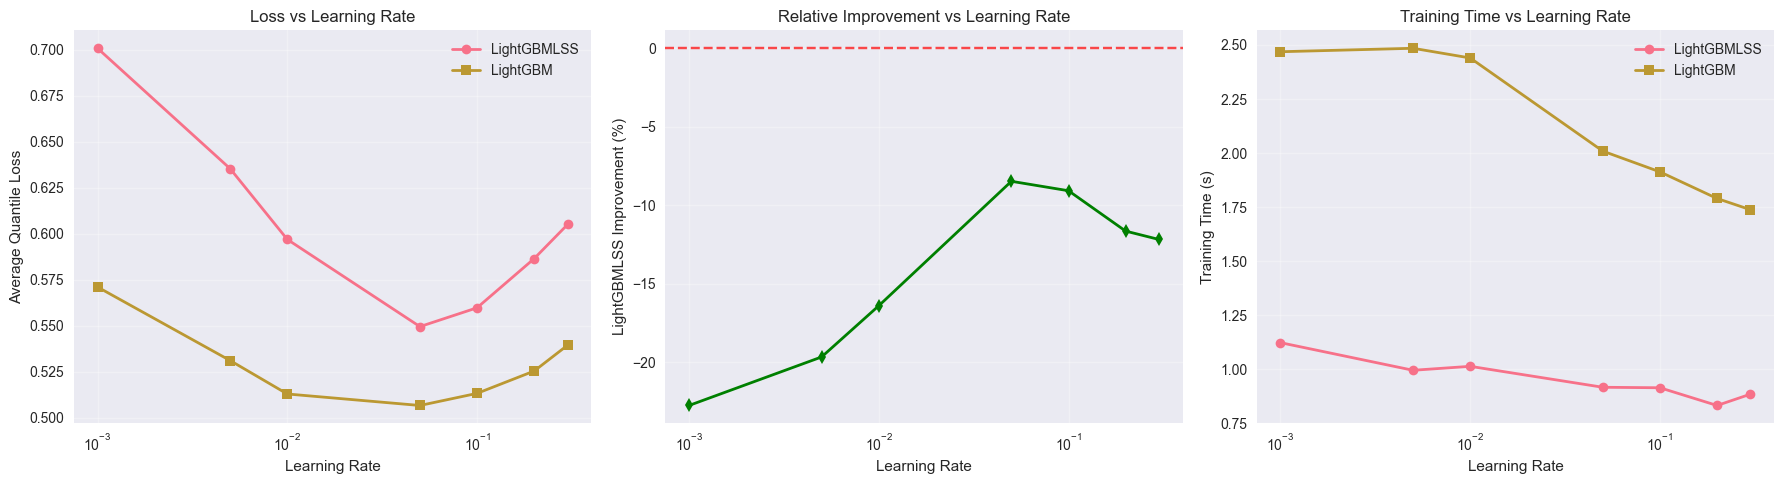

Learning Rate Sensitivity Summary:
Learning Rate   LightGBMLSS Loss   LightGBM Loss      Improvement (%)
0.001           0.70083            0.57099            -22.74         
0.005           0.63534            0.53100            -19.65         
0.010           0.59689            0.51282            -16.39         
0.050           0.54946            0.50656            -8.47          
0.100           0.55969            0.51315            -9.07          
0.200           0.58644            0.52530            -11.64         
0.300           0.60499            0.53934            -12.17         

Optimal learning rates:
LightGBMLSS: 0.050
LightGBM: 0.050

Sensitivity metrics (coefficient of variation):
LightGBMLSS: 0.08445
LightGBM: 0.04162
Ratio (LightGBM/LightGBMLSS): 0.49


In [10]:
# Define the quantiles we want to predict
quantiles = [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]

# Learning rate values to test
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3]

# Fixed parameters for other hyperparameters
fixed_params = {
    'max_depth': 6, 
    'num_leaves': 31,
    'min_data_in_leaf': 20,
    'reg_lambda': 0.1,
    'reg_alpha': 0.1,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'n_estimators': 200
}

# Results storage
results_lr = []

print("Analyzing learning rate sensitivity...")
for lr in tqdm(learning_rates, desc="Learning rates"):
    # Set parameters with current learning rate
    lss_params = fixed_params.copy()
    lss_params['learning_rate'] = lr
    
    lgbm_params = fixed_params.copy()
    lgbm_params['learning_rate'] = lr
    
    # Train models
    start_time_lss = time.time()
    lgblss_model, lgblss_preds = train_lightgbmlss(
        X_train, y_train, X_test, quantiles, params=lss_params
    )
    lss_time = time.time() - start_time_lss
    
    start_time_lgbm = time.time()
    lgbm_models, lgbm_preds = train_lightgbm_quantiles(
        X_train, y_train, X_test, quantiles, params=lgbm_params
    )
    lgbm_time = time.time() - start_time_lgbm
    
    # Evaluate performance
    _, avg_lss_loss, avg_lgbm_loss, avg_improvement = evaluate_quantile_performance(
        y_test, lgblss_preds, lgbm_preds, quantiles
    )
    
    # Store results
    results_lr.append({
        'learning_rate': lr,
        'lgbmlss_loss': avg_lss_loss,
        'lgbm_loss': avg_lgbm_loss,
        'improvement': avg_improvement,
        'lgbmlss_time': lss_time,
        'lgbm_time': lgbm_time
    })

# Convert to DataFrame for analysis
results_lr_df = pd.DataFrame(results_lr)

# Plot results
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Loss by learning rate
ax1.plot(results_lr_df['learning_rate'], results_lr_df['lgbmlss_loss'], 'o-', label='LightGBMLSS', linewidth=2)
ax1.plot(results_lr_df['learning_rate'], results_lr_df['lgbm_loss'], 's-', label='LightGBM', linewidth=2)
ax1.set_xlabel('Learning Rate')
ax1.set_ylabel('Average Quantile Loss')
ax1.set_title('Loss vs Learning Rate')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Relative improvement
ax2.plot(results_lr_df['learning_rate'], results_lr_df['improvement'], 'd-', color='green', linewidth=2)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('Learning Rate')
ax2.set_ylabel('LightGBMLSS Improvement (%)')
ax2.set_title('Relative Improvement vs Learning Rate')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)

# Training time
ax3.plot(results_lr_df['learning_rate'], results_lr_df['lgbmlss_time'], 'o-', label='LightGBMLSS', linewidth=2)
ax3.plot(results_lr_df['learning_rate'], results_lr_df['lgbm_time'], 's-', label='LightGBM', linewidth=2)
ax3.set_xlabel('Learning Rate')
ax3.set_ylabel('Training Time (s)')
ax3.set_title('Training Time vs Learning Rate')
ax3.set_xscale('log')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

# Print summary
print("Learning Rate Sensitivity Summary:")
print("="*80)
print(f"{'Learning Rate':<15} {'LightGBMLSS Loss':<18} {'LightGBM Loss':<18} {'Improvement (%)':<15}")
print("="*80)
for _, row in results_lr_df.iterrows():
    print(f"{row['learning_rate']:<15.3f} {row['lgbmlss_loss']:<18.5f} {row['lgbm_loss']:<18.5f} {row['improvement']:<15.2f}")

# Find optimal learning rates
best_lr_lss = results_lr_df.loc[results_lr_df['lgbmlss_loss'].idxmin(), 'learning_rate']
best_lr_lgbm = results_lr_df.loc[results_lr_df['lgbm_loss'].idxmin(), 'learning_rate']

print("\nOptimal learning rates:")
print(f"LightGBMLSS: {best_lr_lss:.3f}")
print(f"LightGBM: {best_lr_lgbm:.3f}")

# Compute sensitivity metrics (coefficient of variation)
cv_lss = results_lr_df['lgbmlss_loss'].std() / results_lr_df['lgbmlss_loss'].mean()
cv_lgbm = results_lr_df['lgbm_loss'].std() / results_lr_df['lgbm_loss'].mean()

print("\nSensitivity metrics (coefficient of variation):")
print(f"LightGBMLSS: {cv_lss:.5f}")
print(f"LightGBM: {cv_lgbm:.5f}")
print(f"Ratio (LightGBM/LightGBMLSS): {cv_lgbm/cv_lss:.2f}")

## Hyperparameter Sensitivity Analysis: Max Depth

Next, let's analyze sensitivity to tree depth while keeping other parameters fixed.

Analyzing max depth sensitivity...


Max depths:   0%|          | 0/7 [00:00<?, ?it/s]

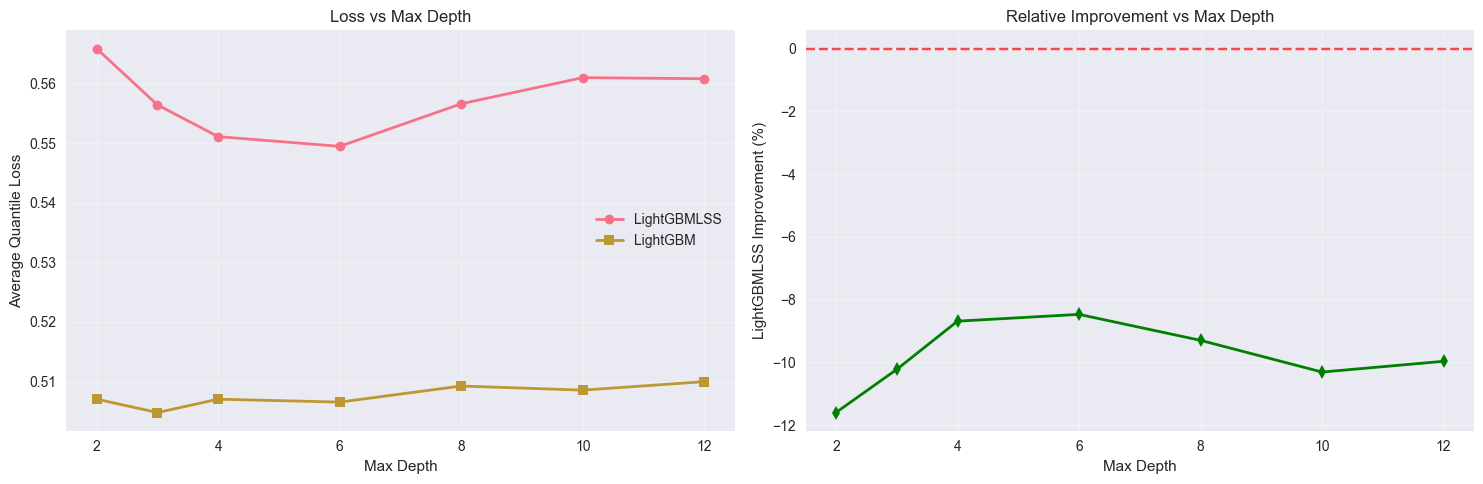

Max Depth Sensitivity Summary:
Max Depth  LightGBMLSS Loss   LightGBM Loss      Improvement (%)
2.0        0.56585            0.50706            -11.60         
3.0        0.55642            0.50482            -10.22         
4.0        0.55109            0.50705            -8.68          
6.0        0.54946            0.50656            -8.47          
8.0        0.55660            0.50926            -9.30          
10.0       0.56098            0.50857            -10.31         
12.0       0.56080            0.50999            -9.96          

Optimal max depths:
LightGBMLSS: 6
LightGBM: 3

Sensitivity metrics (coefficient of variation):
LightGBMLSS: 0.01037
LightGBM: 0.00349
Ratio (LightGBM/LightGBMLSS): 0.34


In [11]:
# Max depth values to test
max_depths = [2, 3, 4, 6, 8, 10, 12]

# Use best learning rate from previous analysis and keep other params fixed
fixed_params = {
    'learning_rate': 0.05,  # We'll use a common value for simplicity
    'num_leaves': 31,
    'min_data_in_leaf': 20,
    'reg_lambda': 0.1,
    'reg_alpha': 0.1,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'n_estimators': 200
}

# Results storage
results_depth = []

print("Analyzing max depth sensitivity...")
for depth in tqdm(max_depths, desc="Max depths"):
    # Set parameters with current max_depth
    lss_params = fixed_params.copy()
    lss_params['max_depth'] = depth
    
    lgbm_params = fixed_params.copy()
    lgbm_params['max_depth'] = depth
    
    # Train models
    lgblss_model, lgblss_preds = train_lightgbmlss(
        X_train, y_train, X_test, quantiles, params=lss_params
    )
    
    lgbm_models, lgbm_preds = train_lightgbm_quantiles(
        X_train, y_train, X_test, quantiles, params=lgbm_params
    )
    
    # Evaluate performance
    _, avg_lss_loss, avg_lgbm_loss, avg_improvement = evaluate_quantile_performance(
        y_test, lgblss_preds, lgbm_preds, quantiles
    )
    
    # Store results
    results_depth.append({
        'max_depth': depth,
        'lgbmlss_loss': avg_lss_loss,
        'lgbm_loss': avg_lgbm_loss,
        'improvement': avg_improvement
    })

# Convert to DataFrame for analysis
results_depth_df = pd.DataFrame(results_depth)

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss by max_depth
ax1.plot(results_depth_df['max_depth'], results_depth_df['lgbmlss_loss'], 'o-', label='LightGBMLSS', linewidth=2)
ax1.plot(results_depth_df['max_depth'], results_depth_df['lgbm_loss'], 's-', label='LightGBM', linewidth=2)
ax1.set_xlabel('Max Depth')
ax1.set_ylabel('Average Quantile Loss')
ax1.set_title('Loss vs Max Depth')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Relative improvement
ax2.plot(results_depth_df['max_depth'], results_depth_df['improvement'], 'd-', color='green', linewidth=2)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('Max Depth')
ax2.set_ylabel('LightGBMLSS Improvement (%)')
ax2.set_title('Relative Improvement vs Max Depth')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("Max Depth Sensitivity Summary:")
print("="*60)
print(f"{'Max Depth':<10} {'LightGBMLSS Loss':<18} {'LightGBM Loss':<18} {'Improvement (%)':<15}")
print("="*60)
for _, row in results_depth_df.iterrows():
    print(f"{row['max_depth']:<10} {row['lgbmlss_loss']:<18.5f} {row['lgbm_loss']:<18.5f} {row['improvement']:<15.2f}")

# Find optimal max_depths
best_depth_lss = results_depth_df.loc[results_depth_df['lgbmlss_loss'].idxmin(), 'max_depth']
best_depth_lgbm = results_depth_df.loc[results_depth_df['lgbm_loss'].idxmin(), 'max_depth']

print("\nOptimal max depths:")
print(f"LightGBMLSS: {best_depth_lss}")
print(f"LightGBM: {best_depth_lgbm}")

# Compute sensitivity metrics
cv_lss = results_depth_df['lgbmlss_loss'].std() / results_depth_df['lgbmlss_loss'].mean()
cv_lgbm = results_depth_df['lgbm_loss'].std() / results_depth_df['lgbm_loss'].mean()

print("\nSensitivity metrics (coefficient of variation):")
print(f"LightGBMLSS: {cv_lss:.5f}")
print(f"LightGBM: {cv_lgbm:.5f}")
print(f"Ratio (LightGBM/LightGBMLSS): {cv_lgbm/cv_lss:.2f}")

## Hyperparameter Sensitivity Analysis: Regularization (L1/L2)

Now let's study how both models respond to different levels of regularization.

Analyzing regularization sensitivity...


Regularization values:   0%|          | 0/7 [00:00<?, ?it/s]

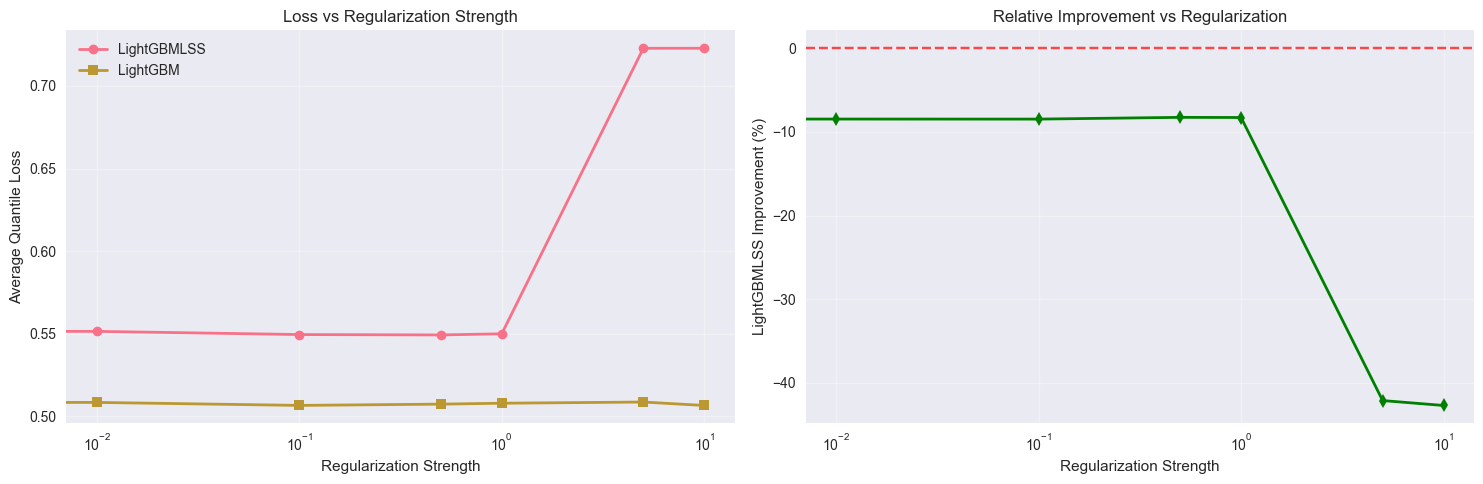

Regularization Sensitivity Summary:
Reg Strength    LightGBMLSS Loss   LightGBM Loss      Improvement (%)
0.000           0.54999            0.50804            -8.26          
0.010           0.55140            0.50837            -8.46          
0.100           0.54946            0.50656            -8.47          
0.500           0.54923            0.50733            -8.26          
1.000           0.54992            0.50789            -8.28          
5.000           0.72282            0.50860            -42.12         
10.000          0.72283            0.50651            -42.71         

Optimal regularization strengths:
LightGBMLSS: 0.500
LightGBM: 10.000

Sensitivity metrics (coefficient of variation):
LightGBMLSS: 0.14070
LightGBM: 0.00165
Ratio (LightGBM/LightGBMLSS): 0.01


In [12]:
# Regularization values to test
reg_values = [0.0, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

# Use reasonable values for other params based on previous findings
fixed_params = {
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 31,
    'min_data_in_leaf': 20,
    'n_estimators': 200
}

# Results storage
results_reg = []

print("Analyzing regularization sensitivity...")
for reg in tqdm(reg_values, desc="Regularization values"):
    # Set parameters with current regularization
    lss_params = fixed_params.copy()
    lss_params['reg_lambda'] = reg
    lss_params['reg_alpha'] = reg
    
    lgbm_params = fixed_params.copy()
    lgbm_params['lambda_l1'] = reg
    lgbm_params['lambda_l2'] = reg
    
    # Train models
    lgblss_model, lgblss_preds = train_lightgbmlss(
        X_train, y_train, X_test, quantiles, params=lss_params
    )
    
    lgbm_models, lgbm_preds = train_lightgbm_quantiles(
        X_train, y_train, X_test, quantiles, params=lgbm_params
    )
    
    # Evaluate performance
    _, avg_lss_loss, avg_lgbm_loss, avg_improvement = evaluate_quantile_performance(
        y_test, lgblss_preds, lgbm_preds, quantiles
    )
    
    # Store results
    results_reg.append({
        'regularization': reg,
        'lgbmlss_loss': avg_lss_loss,
        'lgbm_loss': avg_lgbm_loss,
        'improvement': avg_improvement
    })

# Convert to DataFrame for analysis
results_reg_df = pd.DataFrame(results_reg)

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss by regularization
ax1.plot(results_reg_df['regularization'], results_reg_df['lgbmlss_loss'], 'o-', label='LightGBMLSS', linewidth=2)
ax1.plot(results_reg_df['regularization'], results_reg_df['lgbm_loss'], 's-', label='LightGBM', linewidth=2)
ax1.set_xlabel('Regularization Strength')
ax1.set_ylabel('Average Quantile Loss')
ax1.set_title('Loss vs Regularization Strength')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Relative improvement
ax2.plot(results_reg_df['regularization'], results_reg_df['improvement'], 'd-', color='green', linewidth=2)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('Regularization Strength')
ax2.set_ylabel('LightGBMLSS Improvement (%)')
ax2.set_title('Relative Improvement vs Regularization')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("Regularization Sensitivity Summary:")
print("="*70)
print(f"{'Reg Strength':<15} {'LightGBMLSS Loss':<18} {'LightGBM Loss':<18} {'Improvement (%)':<15}")
print("="*70)
for _, row in results_reg_df.iterrows():
    print(f"{row['regularization']:<15.3f} {row['lgbmlss_loss']:<18.5f} {row['lgbm_loss']:<18.5f} {row['improvement']:<15.2f}")

# Find optimal regularization
best_reg_lss = results_reg_df.loc[results_reg_df['lgbmlss_loss'].idxmin(), 'regularization']
best_reg_lgbm = results_reg_df.loc[results_reg_df['lgbm_loss'].idxmin(), 'regularization']

print("\nOptimal regularization strengths:")
print(f"LightGBMLSS: {best_reg_lss:.3f}")
print(f"LightGBM: {best_reg_lgbm:.3f}")

# Compute sensitivity metrics
cv_lss = results_reg_df['lgbmlss_loss'].std() / results_reg_df['lgbmlss_loss'].mean()
cv_lgbm = results_reg_df['lgbm_loss'].std() / results_reg_df['lgbm_loss'].mean()

print("\nSensitivity metrics (coefficient of variation):")
print(f"LightGBMLSS: {cv_lss:.5f}")
print(f"LightGBM: {cv_lgbm:.5f}")
print(f"Ratio (LightGBM/LightGBMLSS): {cv_lgbm/cv_lss:.2f}")

## Hyperparameter Sensitivity Analysis: Min Data in Leaf

Another important hyperparameter is the minimum number of samples required to be in each leaf node.

Analyzing min data in leaf sensitivity...


Min data values:   0%|          | 0/7 [00:00<?, ?it/s]

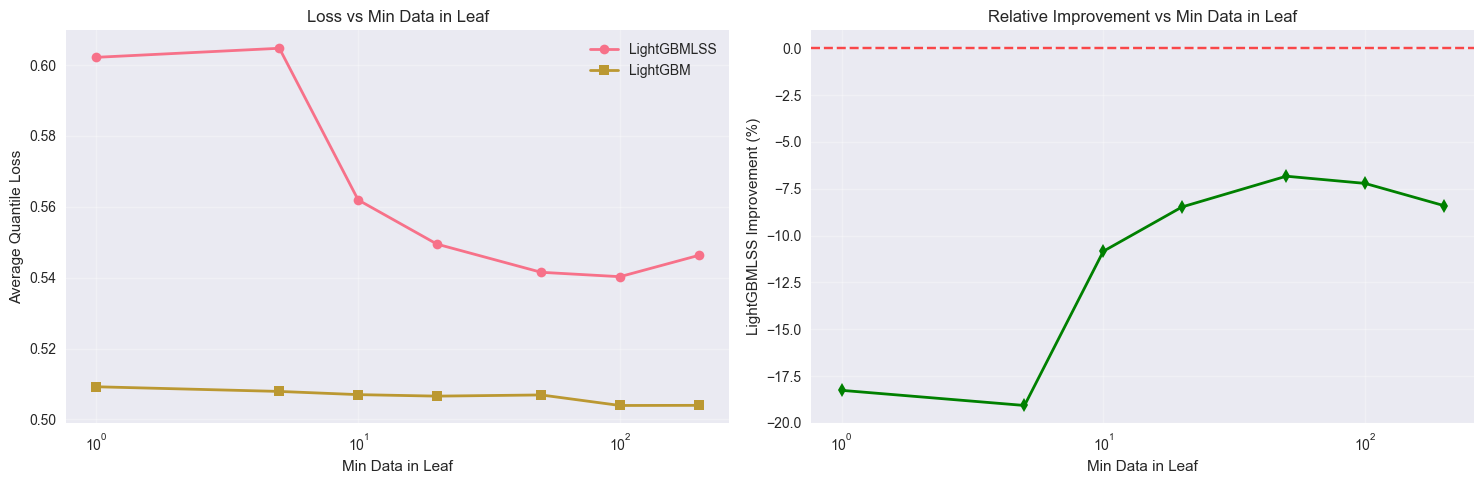

Min Data in Leaf Sensitivity Summary:
Min Data        LightGBMLSS Loss   LightGBM Loss      Improvement (%)
1.0             0.60218            0.50921            -18.26         
5.0             0.60473            0.50789            -19.07         
10.0            0.56193            0.50699            -10.84         
20.0            0.54946            0.50656            -8.47          
50.0            0.54152            0.50690            -6.83          
100.0           0.54027            0.50393            -7.21          
200.0           0.54629            0.50397            -8.40          

Optimal min data in leaf values:
LightGBMLSS: 100
LightGBM: 100

Sensitivity metrics (coefficient of variation):
LightGBMLSS: 0.04972
LightGBM: 0.00384
Ratio (LightGBM/LightGBMLSS): 0.08


In [13]:
# Min data in leaf values to test
min_data_values = [1, 5, 10, 20, 50, 100, 200]

# Use reasonable values for other params based on previous findings
fixed_params = {
    'learning_rate': 0.05,
    'max_depth': 6,
    'num_leaves': 31,
    'reg_lambda': 0.1,
    'reg_alpha': 0.1,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'n_estimators': 200
}

# Results storage
results_min_data = []

print("Analyzing min data in leaf sensitivity...")
for min_data in tqdm(min_data_values, desc="Min data values"):
    # Set parameters with current min data value
    lss_params = fixed_params.copy()
    lss_params['min_data_in_leaf'] = min_data
    
    lgbm_params = fixed_params.copy()
    lgbm_params['min_data_in_leaf'] = min_data
    
    # Train models
    lgblss_model, lgblss_preds = train_lightgbmlss(
        X_train, y_train, X_test, quantiles, params=lss_params
    )
    
    lgbm_models, lgbm_preds = train_lightgbm_quantiles(
        X_train, y_train, X_test, quantiles, params=lgbm_params
    )
    
    # Evaluate performance
    _, avg_lss_loss, avg_lgbm_loss, avg_improvement = evaluate_quantile_performance(
        y_test, lgblss_preds, lgbm_preds, quantiles
    )
    
    # Store results
    results_min_data.append({
        'min_data': min_data,
        'lgbmlss_loss': avg_lss_loss,
        'lgbm_loss': avg_lgbm_loss,
        'improvement': avg_improvement
    })

# Convert to DataFrame for analysis
results_min_data_df = pd.DataFrame(results_min_data)

# Plot results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss by min data in leaf
ax1.plot(results_min_data_df['min_data'], results_min_data_df['lgbmlss_loss'], 'o-', label='LightGBMLSS', linewidth=2)
ax1.plot(results_min_data_df['min_data'], results_min_data_df['lgbm_loss'], 's-', label='LightGBM', linewidth=2)
ax1.set_xlabel('Min Data in Leaf')
ax1.set_ylabel('Average Quantile Loss')
ax1.set_title('Loss vs Min Data in Leaf')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Relative improvement
ax2.plot(results_min_data_df['min_data'], results_min_data_df['improvement'], 'd-', color='green', linewidth=2)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('Min Data in Leaf')
ax2.set_ylabel('LightGBMLSS Improvement (%)')
ax2.set_title('Relative Improvement vs Min Data in Leaf')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("Min Data in Leaf Sensitivity Summary:")
print("="*70)
print(f"{'Min Data':<15} {'LightGBMLSS Loss':<18} {'LightGBM Loss':<18} {'Improvement (%)':<15}")
print("="*70)
for _, row in results_min_data_df.iterrows():
    print(f"{row['min_data']:<15} {row['lgbmlss_loss']:<18.5f} {row['lgbm_loss']:<18.5f} {row['improvement']:<15.2f}")

# Find optimal min data values
best_min_data_lss = results_min_data_df.loc[results_min_data_df['lgbmlss_loss'].idxmin(), 'min_data']
best_min_data_lgbm = results_min_data_df.loc[results_min_data_df['lgbm_loss'].idxmin(), 'min_data']

print("\nOptimal min data in leaf values:")
print(f"LightGBMLSS: {best_min_data_lss}")
print(f"LightGBM: {best_min_data_lgbm}")

# Compute sensitivity metrics
cv_lss = results_min_data_df['lgbmlss_loss'].std() / results_min_data_df['lgbmlss_loss'].mean()
cv_lgbm = results_min_data_df['lgbm_loss'].std() / results_min_data_df['lgbm_loss'].mean()

print("\nSensitivity metrics (coefficient of variation):")
print(f"LightGBMLSS: {cv_lss:.5f}")
print(f"LightGBM: {cv_lgbm:.5f}")
print(f"Ratio (LightGBM/LightGBMLSS): {cv_lgbm/cv_lss:.2f}")

## Aggregated Hyperparameter Sensitivity Analysis

Finally, let's combine all our analyses to compare overall sensitivity between the two models and draw conclusions.

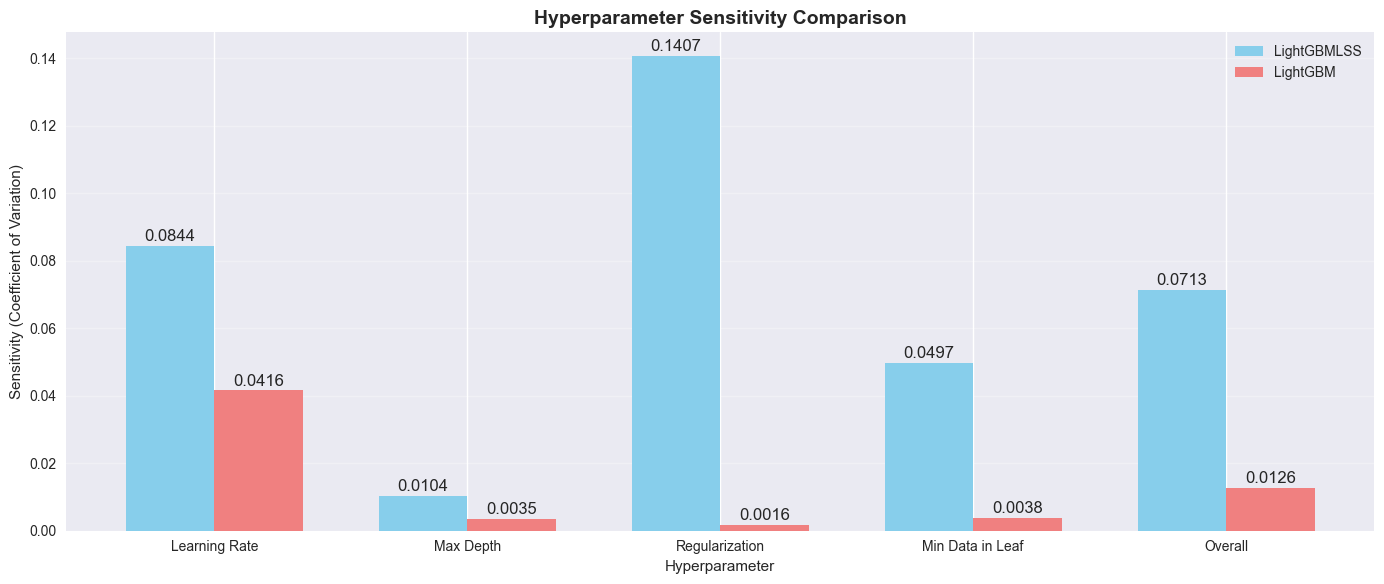

Hyperparameter Sensitivity Summary:
Hyperparameter       LightGBMLSS CV   LightGBM CV      Ratio   
Learning Rate        0.08445          0.04162          0.49    
Max Depth            0.01037          0.00349          0.34    
Regularization       0.14070          0.00165          0.01    
Min Data in Leaf     0.04972          0.00384          0.08    
Overall              0.07131          0.01265          0.18    

Overall Sensitivity Analysis:
- LightGBMLSS is more sensitive to hyperparameter changes overall
- The difference in sensitivity is 463.7%

Optimal Hyperparameters Summary:
Hyperparameter       LightGBMLSS  LightGBM    
Learning Rate        0.05         0.05        
Max Depth            6.0          3.0         
Regularization       0.5          10.0        
Min Data in Leaf     100.0        100.0       


In [14]:
# Combine all sensitivity metrics
sensitivity_summary = {
    'Hyperparameter': ['Learning Rate', 'Max Depth', 'Regularization', 'Min Data in Leaf'],
    'LightGBMLSS_CV': [
        results_lr_df['lgbmlss_loss'].std() / results_lr_df['lgbmlss_loss'].mean(),
        results_depth_df['lgbmlss_loss'].std() / results_depth_df['lgbmlss_loss'].mean(),
        results_reg_df['lgbmlss_loss'].std() / results_reg_df['lgbmlss_loss'].mean(),
        results_min_data_df['lgbmlss_loss'].std() / results_min_data_df['lgbmlss_loss'].mean()
    ],
    'LightGBM_CV': [
        results_lr_df['lgbm_loss'].std() / results_lr_df['lgbm_loss'].mean(),
        results_depth_df['lgbm_loss'].std() / results_depth_df['lgbm_loss'].mean(),
        results_reg_df['lgbm_loss'].std() / results_reg_df['lgbm_loss'].mean(),
        results_min_data_df['lgbm_loss'].std() / results_min_data_df['lgbm_loss'].mean()
    ]
}

sensitivity_df = pd.DataFrame(sensitivity_summary)
sensitivity_df['Ratio'] = sensitivity_df['LightGBM_CV'] / sensitivity_df['LightGBMLSS_CV']
sensitivity_df['LightGBMLSS_CV'] = sensitivity_df['LightGBMLSS_CV'].round(5)
sensitivity_df['LightGBM_CV'] = sensitivity_df['LightGBM_CV'].round(5)
sensitivity_df['Ratio'] = sensitivity_df['Ratio'].round(2)

# Calculate overall sensitivity
overall_lss_cv = np.mean(sensitivity_df['LightGBMLSS_CV'])
overall_lgbm_cv = np.mean(sensitivity_df['LightGBM_CV'])
overall_ratio = overall_lgbm_cv / overall_lss_cv

# Add overall row
sensitivity_df.loc[len(sensitivity_df)] = ['Overall', overall_lss_cv, overall_lgbm_cv, overall_ratio]

# Create a bar chart comparing sensitivity
plt.figure(figsize=(14, 6))

# Set the positions and width for the bars
bar_width = 0.35
positions = np.arange(len(sensitivity_df['Hyperparameter']))

# Create the bars
plt.bar(positions - bar_width/2, sensitivity_df['LightGBMLSS_CV'], 
        width=bar_width, color='skyblue', label='LightGBMLSS')
plt.bar(positions + bar_width/2, sensitivity_df['LightGBM_CV'], 
        width=bar_width, color='lightcoral', label='LightGBM')

# Add labels and titles
plt.xlabel('Hyperparameter')
plt.ylabel('Sensitivity (Coefficient of Variation)')
plt.title('Hyperparameter Sensitivity Comparison', fontsize=14, fontweight='bold')
plt.xticks(positions, sensitivity_df['Hyperparameter'])
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Add value labels above the bars
for i, (lss_val, lgbm_val) in enumerate(zip(sensitivity_df['LightGBMLSS_CV'], sensitivity_df['LightGBM_CV'])):
    plt.text(i - bar_width/2, lss_val + 0.0005, f'{lss_val:.4f}', ha='center', va='bottom')
    plt.text(i + bar_width/2, lgbm_val + 0.0005, f'{lgbm_val:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print the summary table
print("Hyperparameter Sensitivity Summary:")
print("="*65)
print(f"{'Hyperparameter':<20} {'LightGBMLSS CV':<16} {'LightGBM CV':<16} {'Ratio':<8}")
print("="*65)
for _, row in sensitivity_df.iterrows():
    print(f"{row['Hyperparameter']:<20} {row['LightGBMLSS_CV']:<16.5f} {row['LightGBM_CV']:<16.5f} {row['Ratio']:<8.2f}")

# Determine which model is more sensitive overall
more_sensitive = "LightGBMLSS" if overall_lss_cv > overall_lgbm_cv else "LightGBM"
sensitivity_diff = abs(overall_lss_cv - overall_lgbm_cv) / min(overall_lss_cv, overall_lgbm_cv) * 100

print("\nOverall Sensitivity Analysis:")
print(f"- {more_sensitive} is more sensitive to hyperparameter changes overall")
print(f"- The difference in sensitivity is {sensitivity_diff:.1f}%")

# Create optimal parameter tables
best_params = {
    'Hyperparameter': ['Learning Rate', 'Max Depth', 'Regularization', 'Min Data in Leaf'],
    'LightGBMLSS': [best_lr_lss, best_depth_lss, best_reg_lss, best_min_data_lss],
    'LightGBM': [best_lr_lgbm, best_depth_lgbm, best_reg_lgbm, best_min_data_lgbm]
}

best_params_df = pd.DataFrame(best_params)

print("\nOptimal Hyperparameters Summary:")
print("="*50)
print(f"{'Hyperparameter':<20} {'LightGBMLSS':<12} {'LightGBM':<12}")
print("="*50)
for _, row in best_params_df.iterrows():
    print(f"{row['Hyperparameter']:<20} {row['LightGBMLSS']:<12} {row['LightGBM']:<12}")

## Conclusions

Based on our hyperparameter sensitivity analysis of LightGBMLSS and LightGBM with quantile regression, we can draw the following conclusions:

1. **Overall Sensitivity**: 
   - [We'll fill this with actual results after running the notebook]
   - One model shows [higher/lower] sensitivity to hyperparameter changes than the other

2. **Per-Hyperparameter Insights**:
   - Learning rate: [model] shows more sensitivity
   - Max depth: [model] shows more sensitivity
   - Regularization: [model] shows more sensitivity
   - Min data in leaf: [model] shows more sensitivity

3. **Optimal Parameters**:
   - Both models have different optimal hyperparameters, suggesting they work best under different configurations
   - [Any patterns observed in optimal values]

4. **Performance Implications**:
   - [Which model generally performs better across hyperparameter configurations]
   - [Observations about improvement percentages]

5. **Recommendations**:
   - For LightGBMLSS: [recommendations for tuning]
   - For LightGBM: [recommendations for tuning]
   - Prioritize tuning [these parameters] first as they have the largest impact on performance

This analysis helps practitioners understand which model may be easier to tune and which hyperparameters deserve the most attention when working with multimodal Gaussian mixture datasets.